In [1]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, min, argmin, unravel_index, log, tan
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator

### We first find the conductivity for CPA at large kR

In [2]:
M = 1000
epsilon = 2
x_1 = 300
x_2 = 304
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [3]:
l = 5
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [4]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)
sigmas_asymptotic = 1 + 1j*m*tan(y-l*pi/2)

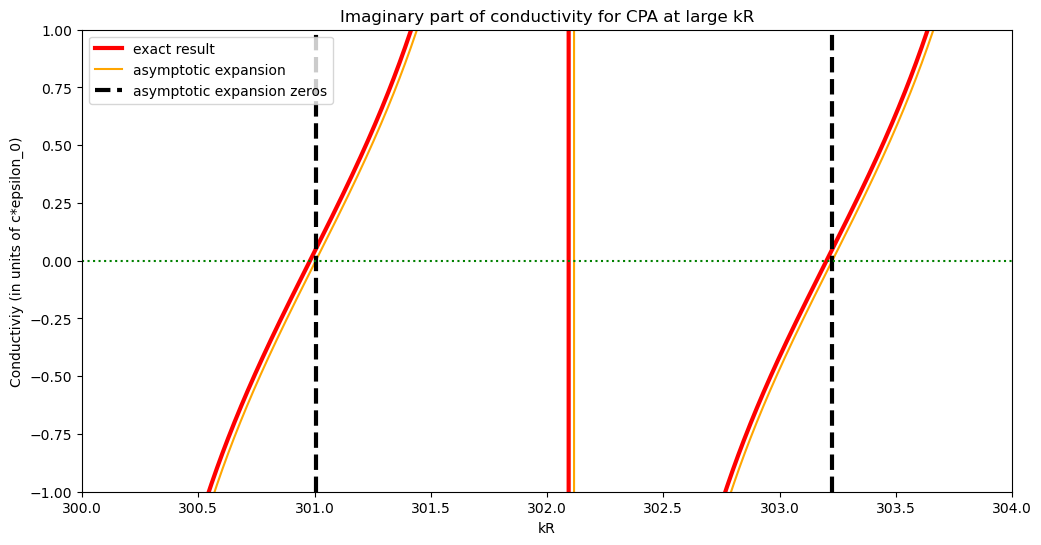

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax.set_ylim(-1, 1)
ax.vlines([pi/2/m]+ pi * linspace(1, 10000, 10000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.set_xlim(x_1, x_2);
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

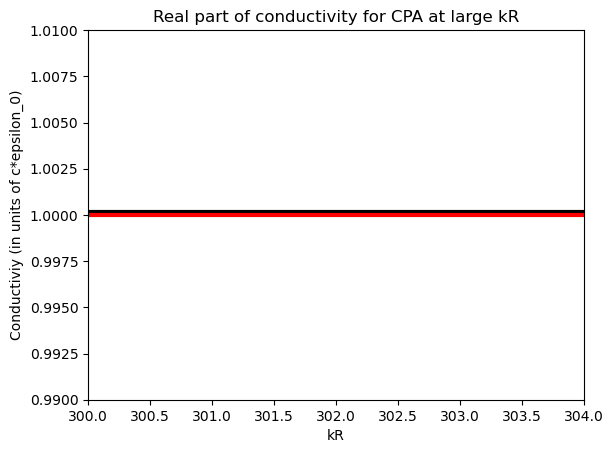

In [6]:
plt.plot(x, sigmas[0, :], color="black", linewidth=3)
plt.plot(x, sigmas_asymptotic.real, color="red", linewidth=3)
plt.xlim(x_1, x_2);
plt.ylim(0.99, 1.01)
plt.xlabel("kR")
plt.ylabel("Conductiviy (in units of c*epsilon_0)");
plt.title("Real part of conductivity for CPA at large kR");

### We verify that the above does indeed correspond to CPA

In [7]:
s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])/x))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  1.0335983668531242e-27


### Now we look at subwavelength coherent perfect absorption

In [8]:
M = 10000
epsilon = 2.2
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [9]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
# The quasistatic dispersion (from the plasmon dispersion)
quasistatic_dispersion = x*(l*epsilon+(l+1))/(l*(l+1))

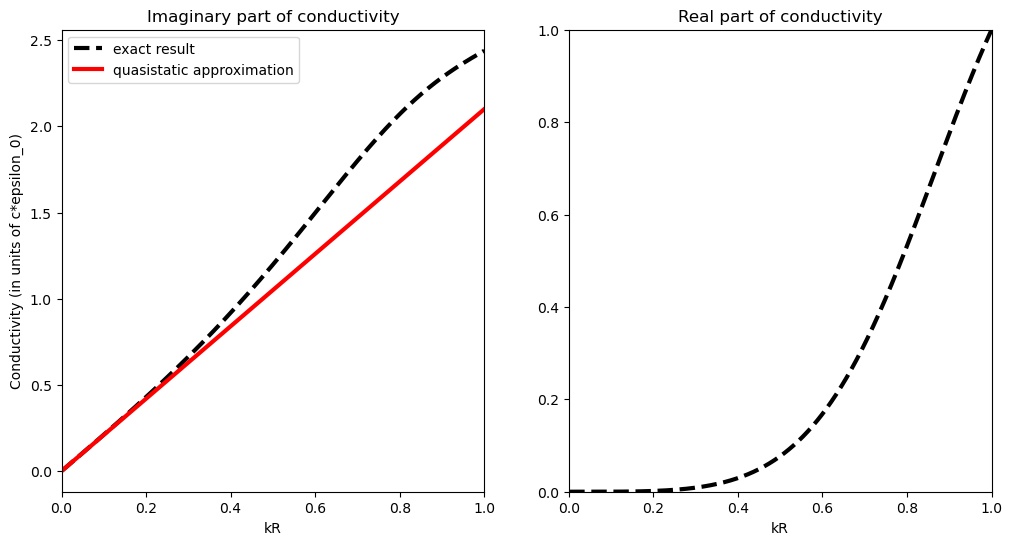

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
#ax1.set_ylim(0, 2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");

### We verify that the above conductivity profile corresponds to CPA

In [11]:
s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])/x))**2
tm_numerator = abs(e_r_cpa_numerator(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])/x))
print("Maximum value for |s|^2: ", s_sqrds.max())
print("Maximum (absolute) value for the cpa numerator", tm_numerator.max())

Maximum value for |s|^2:  5.2873754400754396e-14
Maximum (absolute) value for the cpa numerator 4.547473508864641e-13


In [12]:
hbar = 6.67*1e-16 # hbar in eV*seconds
tau = 6.4*1e-13 # scattering time in seconds
c = 3*10**17; # speed of light in nanometers per second
alpha = 1/137; # fine structure constant

In [13]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;

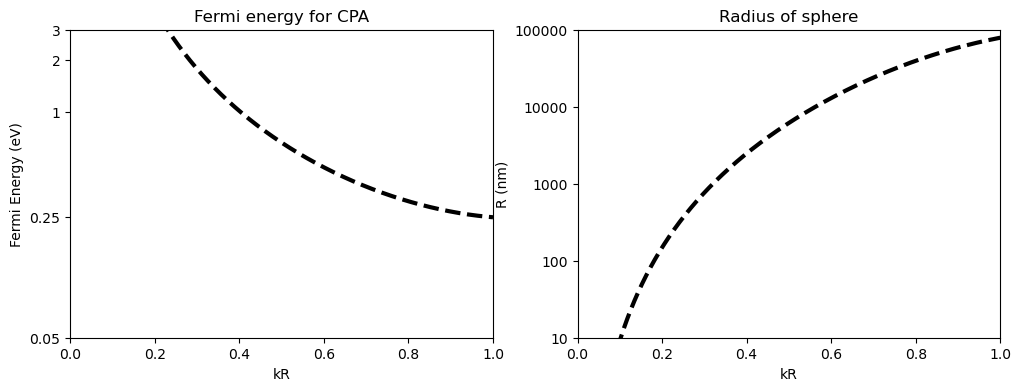

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(x, log(E_F), color="black", linestyle="dashed", linewidth=3)
ax1.set_yticks([log(0.05), log(0.25), log(1), log(2), log(3)], [0.05, 0.25, 1, 2, 3])
ax1.set_ylim(log(0.05), log(3));
ax1.set_xlim(0, 1)
ax1.set_xlabel("kR");
ax1.set_ylabel("Fermi Energy (eV)");
ax1.set_title("Fermi energy for CPA");

ax2.plot(x, log(a), color="black", linestyle="dashed", linewidth=3)
ax2.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
ax2.set_ylim(log(1e1), log(1e5));
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_ylabel("R (nm)");
ax2.set_title("Radius of sphere");

### We verify that the above Fermi energies/radii correspond to the CPA conductivities

In [15]:
omega = c*x/a
graphene_cpa_sigmas = 4*1j*alpha*E_F/(hbar*(omega+1j/tau))
print("Maximum deviation from CPA conductivity (in normalized absolute value): ", abs((graphene_cpa_sigmas - sigma_real - 1j*sigma_imaginary)/graphene_cpa_sigmas).max())

Maximum deviation from CPA conductivity (in normalized absolute value):  8.135530171035477e-16


### Now we calculate the bandwidth for CPA

In [34]:
idxs = [5000, 6000, 7000, 8000, 9000]
M = int(1e5)
omega_range = linspace(0.1, 30, M)*1e12 # frequency range we examine (in Hertz)
s_sqrds = zeros((len(idxs), M))

for (sq_idx, idx) in enumerate(idxs):
    x_range = omega_range * a[idx]/c # keep radius fixed
    sigma_range = 4*1j*alpha*E_F[idx]/(hbar*(omega_range+1j/tau)) # Graphene conductivity over the frequency range
    g_omega_range = sigma_range*1j/x_range
    s_sqrds[sq_idx, :] = abs(e_r_cpa(l, x_range, epsilon, g_omega_range))**2

In [40]:
print("Minimum |s|^2 for each index: ", s_sqrds.min((1)))

Minimum |s|^2 for each index:  [8.85733324e-09 1.26302802e-10 1.04126619e-11 8.95105123e-10
 2.90561810e-10]


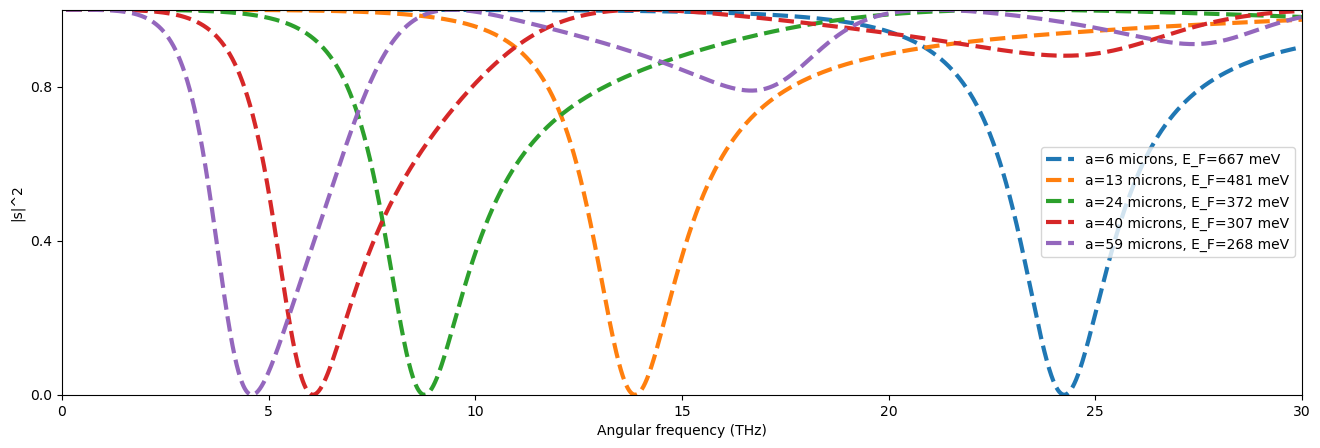

In [39]:
fig, ax = plt.subplots(figsize=(16, 5))
for (sq_idx, idx) in enumerate(idxs):
    ax.plot(omega_range/1e12, s_sqrds[sq_idx], linestyle="dashed", linewidth=3, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.4, 0.8])
ax.set_xlim(0, 30);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");
ax.legend();

### Transverse Electric modes

In [71]:
M = 1000
epsilon = 12
x_1 = 1e-3
x_2 = 0.09
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

In [72]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
small_sphere_dispersion = -(2*l+1)/x

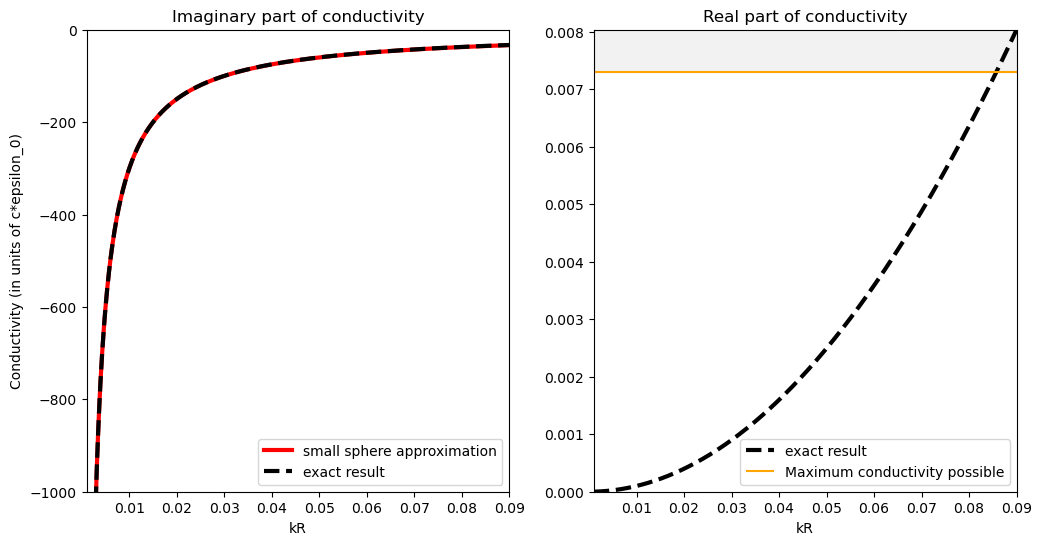

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_sphere_dispersion, label="small sphere approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_ylim(-1000, 0)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.set_ylim(0, )
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.legend();

### We check that the above indeed corresponds to CPA

In [94]:
s_sqrds = abs(h_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])*x))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  3.877422304555238e-14


In [97]:
E_F_1 = (hbar/tau)*(alpha+sqrt(alpha**2-sigma_real**2))/(2*sigma_real);
E_F_2 = (hbar/tau)*(alpha-sqrt(alpha**2-sigma_real**2))/(2*sigma_real);

a_1 = c*x*hbar/(2*E_F_1);
a_2 = c*x*hbar/(2*E_F_2);

In [99]:
x.shape

(1000,)

### We verify that the Fermi energies/radii give us the correct real part of the conductivity 

In [102]:
for (a, E_F) in zip([a_1, a_2], [E_F_1, E_F_2]):
    omega = c*x/a
    graphene_cpa_sigmas = (4*1j*alpha*E_F/(hbar*(omega+1j/tau))).real
    sigma_deviations =  abs((graphene_cpa_sigmas - sigma_real)/graphene_cpa_sigmas)
    sigma_deviations = np.where(np.isnan(sigma_deviations), 0, sigma_deviations)
    print("Maximum deviation from CPA conductivity (in normalized absolute value): ", sigma_deviations.max())

Maximum deviation from CPA conductivity (in normalized absolute value):  6.268468166667832e-16
Maximum deviation from CPA conductivity (in normalized absolute value):  6.155487159417475e-09


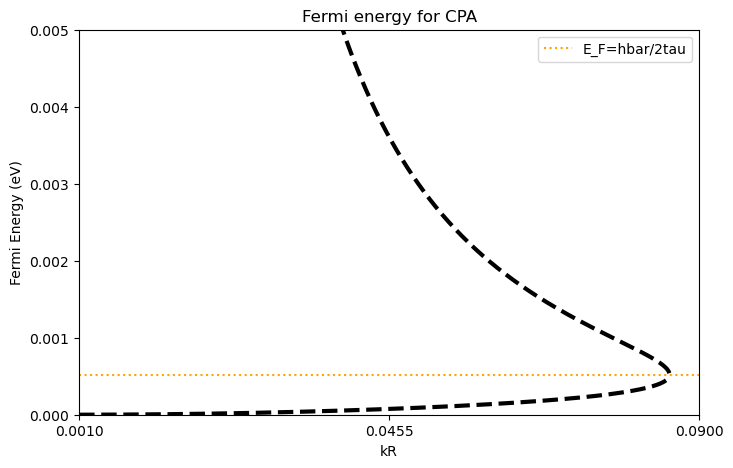

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, E_F_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, E_F_2, color="black", linestyle="dashed", linewidth=3)

ax.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax.set_xlim(x_1, x_2)
ax.set_ylim(0, 0.005)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.hlines([hbar/(2*tau)], x_1, x_2, linestyle="dotted", color="orange", label="E_F=hbar/2tau")
ax.legend()
ax.set_title("Fermi energy for CPA");

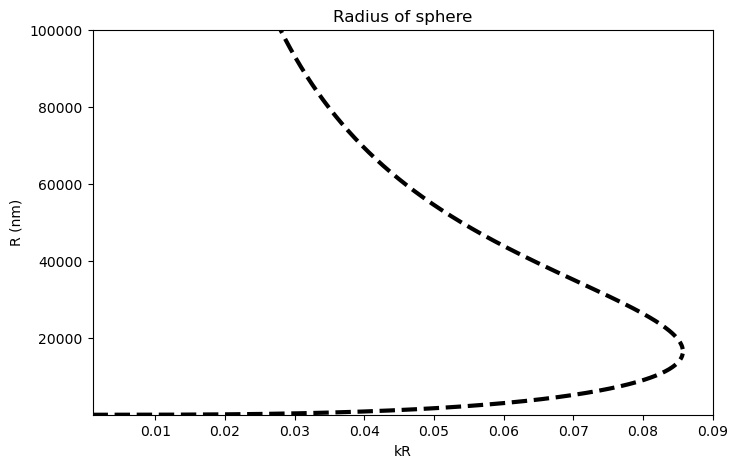

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, a_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, a_2, color="black", linestyle="dashed", linewidth=3)

#ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
#ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(x_1, x_2)
ax.set_ylim(10, 100000)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of sphere");
ax.set_xlim(x_1, x_2);